## CSCI-4041 - Algorithms - Chapter 12 - Binary Search Tree

### Joy Upton Azzam

### 2/14/2026

<mark>_____________________________________________________________________________________</mark>

### 1. Binary Search Tree

In [1]:
class binarysearchtree:
    """a linked-binary search tree based on chapter 12 of CLRS"""
    
    ##################################################################### nested sub-class for nodes
    class node:
        """(nested) node class for linkedlist"""
        
        def __init__(self,k=None,parent=None,left_child=None,right_child=None):
            """constructor for node objects"""
            self.p = parent
            self.left = left_child
            self.right = right_child
            self.key = k
    #####################################################################

    def __init__(self):
        """constructor for the binarytree class objects"""
        self.root = None
    
    def search(self,x,k):
        """searches for key k in the tree and returns the node"""
        if x == None or k == x.key:
            return x
        if k < x.key:
            return self.search(x.left,k)
        else:
            return self.search(x.right,k)
    
    def min(self,x):
        """returns the node which is smallest in the sub-tree rooted at p"""
        while x.left:
            x = x.left # move down and left
        return x       # return previous (non-null) node
    
    def max(self,x):
        """returns the node which is largest in the sub-tree rooted at p"""
        while x.right:
            x = x.right # move down and right
        return x       # return previous (non-null) node
    
    def insert(self,k):
        """insert key k into the tree"""
        z = self.node(k)    # create a node for key k
        
        x = self.root
        y = None
        while x != None:
            y = x
            if z.key < x.key:
                x = x.left
            else:
                x = x.right
        # add z as a child of parent y
        z.p = y # set parent link for z
        if y == None:
            self.root = z
        elif z.key < y.key:
            y.left = z      # link z to parent (as left child)
        else:
            y.right = z     # link z as a right child

    def transplant(self,u,v):
        """delete sub-trees rooted at u and replace with sub-tree from v"""
        
        if u.p == None:     # check if u is the root
            self.root = v   # set root(u) to be v
        elif u == u.p.left: # check if u is a left child
            u.p.left = v    # set parents left child to v
        else:
            u.p.right = v   # set parents right child to v
        if v != None:
            v.p = u.p
    
    def delete(self,k):
        """deletes key k from the tree"""
        x = self.root
        z = None
        while x != None:
            z = x
            if z.key == k:
                break
            elif k < x.key:
                x = x.left
            else:
                x = x.right
        if z.key == k:        # check if we found key k
            print("key =",k,"was found")
            if z.left == None:
                self.transplant(z,z.right)
            elif z.right == None:
                self.transplant(z,z.left)
            else:
                y = self.min(z.right)
                if y != z.right:
                    self.transplant(y,y.right)
                    y.right = z.right
                    y.right.p = y
                self.transplant(z,y)
                y.left = z.left
                y.left.p = y

<mark>_____________________________________________________________________________________</mark>

### 2. Printing Utility Functions for Link-based Trees

This version is slightly different than that from the previous file. The data structures used for the coordinate information was switched for the array-based tree, so I updated this code to use a similar design. In this case, we don't have indices (integers) for each node, so I have used a python dictionary which is keyed by the reference to the node itself. The coords structure still holds the same information for plotting: x-coordinate, y-coordinate, node key, reference to the parent node. The last item is used to draw the edges of the tree.

In [2]:
def get_coordinates(T):
    """traverses a binary linked tree in-order computing the coordinates and saving information as needed"""
    
    def in_order(node,depth):
        """(recursive) in-order traversal of tree starting from node p"""
        nonlocal x,coords
        
        if node:
            in_order(node.left,depth+1)
            
            #------------------------in-order actions--------------------------------------
            # coordinate data[node reference]  =  (  in-order # , depth , key , parent reference )
            coords[node] = (x,-depth,node.key,node.p)
            x += 1                                    # update count
            #------------------------------------------------------------------------------
            
            in_order(node.right,depth+1)
    
    x = 0              # initialize the count of nodes (x-coordinate)
    coords = {}        # data dictionary
    
    in_order(T.root,0) # start the traversal to compute coordinates
    
    return coords      # return (in-order) coordinate set with parent references

In [3]:
import matplotlib.pyplot as plt


def PrintTree(T,scale=0.5,node_size=500,font=12):
    """Creates a scatter plot of a binary linked tree"""
    
    fig, ax = plt.subplots()            # create image (figure/axis) object
    
    coords = get_coordinates(T)         # call recursive coordinate code

    b = 0.75 # outer border for image
    ax.set_xlim([-b, len(coords)])    # set the image frame (axis) limits
    ax.set_ylim([min([data[1] for hash_key,data in coords.items()])-b, b])
    
    for hash_key,data in coords.items():      # loop over the (hash)keys and values of coordinate data dictionary
        x,y,key,parent = data         # extract data parts (node
        # Plot the point for the node
        ax.scatter([x],[y],s=node_size,zorder=2,color="olive")
        
        # Add the annotation for the text of the nodes key
        ax.annotate(str(key), xy=(x,y), xytext=(x,y), 
                    fontsize=font, ha='center',va='center',zorder=3)
        
        # Add the lines for parent child-relationship
        if parent:
            px,py,_1,_1 = coords[parent] # extract parent data from dictionary
            ax.annotate("",
                    xy=(px,py), xytext=(x,y),
                    arrowprops=dict(arrowstyle="-",connectionstyle="arc3",color="darkgoldenrod")
                   ,zorder=1)
    
    plt.gcf().set_size_inches(16*scale, 9*scale)    # set figure size
    plt.show()                                      # display the figure

<mark>_____________________________________________________________________________________</mark>

### 3. Example Code / Usage

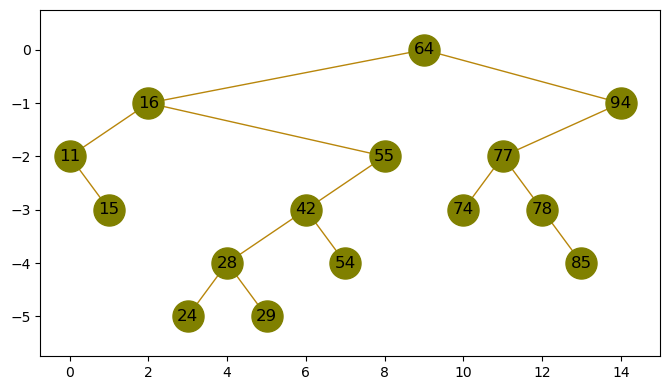

min key = 11
searching for key = 28
node with key = 28
max key = 94
deleting key k = 42
key = 42 was found


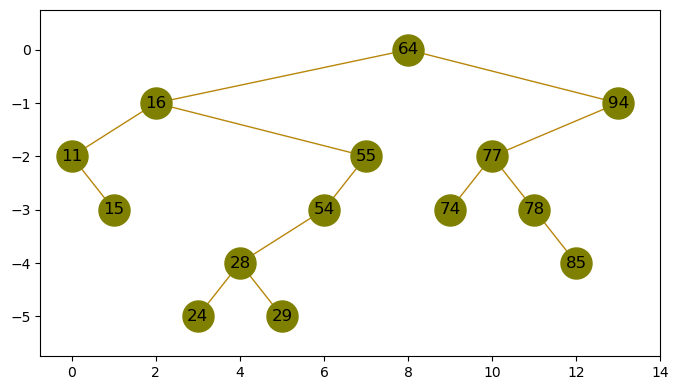

deleting key k = 94
key = 94 was found


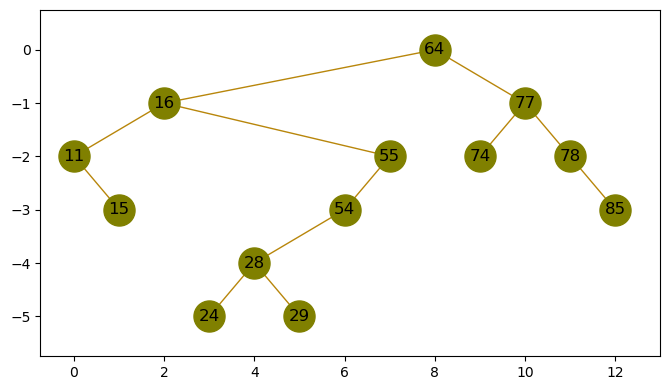

deleting key k = 11
key = 11 was found


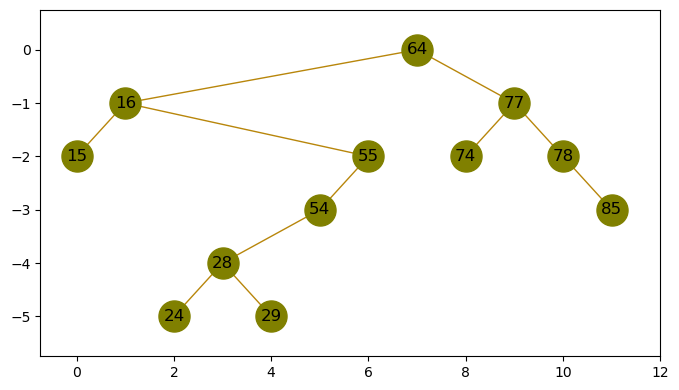

deleting key k = 55
key = 55 was found


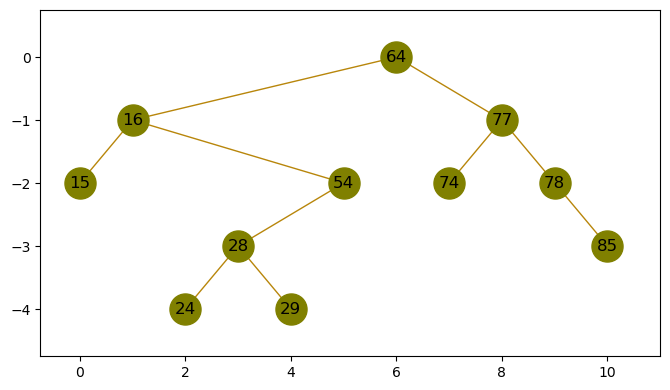

deleting key k = 15
key = 15 was found


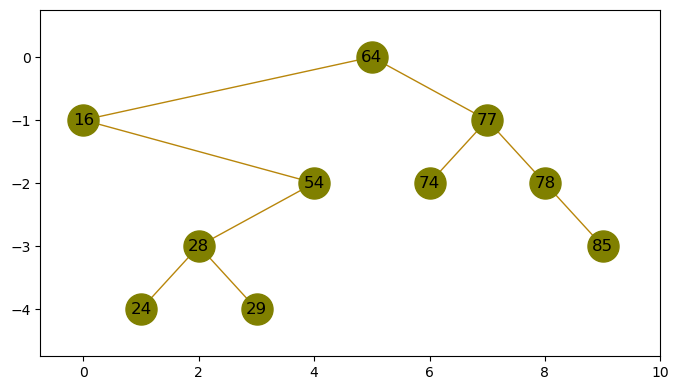

In [22]:
import random

n = 15

BST = binarysearchtree()

keys = []
for i in range(n):
    k = random.randrange(99)
    BST.insert(k)             # call insert
    keys.append(k)
PrintTree(BST)


# min function test
min_node = BST.min(BST.root)    # call min
print("min key =",min_node.key)

# search function test
search_key = random.choice(keys)
print("searching for key =",search_key)
returned_node = BST.search(BST.root,search_key) # call search
if returned_node:
    print("node with key =",returned_node.key)
else:
    print("node not found")

# max function test
max_node = BST.max(BST.root)      # call max
print("max key =",max_node.key)


# deletion tests
for i in range(5):
    rand_key = random.choice(keys)
    print("deleting key k =",rand_key)
    BST.delete(rand_key)   # call delete
    keys.remove(rand_key)
    PrintTree(BST)